In [1]:
from DS_8.config.utils import PATH_KNOWLEDGE_BASE

with open(PATH_KNOWLEDGE_BASE, "r", encoding="utf-8") as f:
    knowledge_text = f.read()

In [2]:
from DS_8.config.utils import chunk_text

chunks = chunk_text(knowledge_text)

print(f"Nombre de chunks : {len(chunks)}")
print(chunks[1][:300])

Nombre de chunks : 32
times faster than the average rate of warming after an ice age. Carbon dioxide from human activities is increasing about 250 times faster than it did from natural sources after the last Ice Age.3 The Evidence for Rapid Climate Change Is Compelling: Global Temperature Is Rising The planet's average s


In [3]:
from sentence_transformers import SentenceTransformer
from DS_8.config.utils import BERT_MODEL
import tqdm as notebook_tqdm

embedding_model = SentenceTransformer(BERT_MODEL)

import numpy as np

chunk_embeddings = embedding_model.encode(
    chunks,
    show_progress_bar=True,
    convert_to_numpy=True
)

embedding_dim = chunk_embeddings.shape[1]
print("Embedding dimension:", embedding_dim)

c:\Applications\Git-OpenClassrooms\DS_8\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

In [ ]:
import faiss

index = faiss.IndexFlatL2(embedding_dim)
index.add(chunk_embeddings)

print("Nombre de vecteurs indexés :", index.ntotal)

Nombre de vecteurs indexés : 32


In [ ]:
from DS_8.config.utils import retrieve_top_k_chunks

test_claim = "Climate change is mainly caused by solar activity"
docs = retrieve_top_k_chunks(test_claim, index, embedding_model, chunks)

for i, doc in enumerate(docs):
    print(f"\n--- Chunk {i+1} ---")
    print(doc[:300])



--- Chunk 1 ---
for many, many centuries. Discover More Topics From NASA Explore Earth Science Earth Science in Action NASA's unique vantage point helps us inform solutions to enhance decision-making, improve livelihoods, and protect our planet. Earth Science Data Facts About Earth [SOURCE: NASA_CLIMATE_WHAT_IS_CLI

--- Chunk 2 ---
[SOURCE: NASA_CLIMATE_EVIDENCE] There is unequivocal evidence that Earth is warming at an unprecedented rate. Human activity is the principal cause. Takeaways The rate of change since the mid-20th century is unprecedented over millennia. Earth's climate has changed throughout history. Just in the la

--- Chunk 3 ---
Sun. TSI incorporates the11-year solar cycleand solar flares/storms from the Sun's surface. Studies show that solar variability has played a role in past climate changes. For example, a decrease in solar activity coupled with increased volcanic activity helped trigger the Little Ice Age. But several


In [ ]:
from groq import Groq
from DS_8.config.secrets import GROQ_API_KEY
from DS_8.config.utils import LLM_MODEL

client = Groq(api_key=GROQ_API_KEY)


In [ ]:
from DS_8.config.utils import load_train_eval_climate_fever_data

df_train, df_eval = load_train_eval_climate_fever_data()

In [ ]:
# from DS_8.config.utils import fact_check_with_groq
# claim = "Climate change does not exist"
# output, _ = fact_check_with_groq(claim, LLM_MODEL, index, embedding_model, chunks, client)
# print(output)

In [ ]:
from DS_8.config.utils import fact_check_with_groq, parse_llm_output

import time
from tqdm import tqdm

predictions = []
raw_outputs = []

SLEEP_TIME = 0.2 

for claim in tqdm(df_eval["claim"]):
    try:
        output, _ = fact_check_with_groq(claim, LLM_MODEL, index, embedding_model, chunks, client)
        label = parse_llm_output(output)
    except Exception as e:
        print("Erreur :", e)
        label = "ERROR"
        output = ""

    predictions.append(label)
    raw_outputs.append(output)

    time.sleep(SLEEP_TIME)

  0%|          | 0/150 [00:00<?, ?it/s]


None


  1%|          | 1/150 [00:00<02:22,  1.05it/s]

Verdict: NOT ENOUGH EVIDENCE  
Justification: None of the provided sources discuss the temperature or weather conditions of the 2009‑2010 winter, nor do they reference any record‑cold events during that period. The sources focus on fire activity, general climate change trends, and solar influences, 
<re.Match object; span=(0, 19), match='verdict: not enough'>


  2%|▏         | 3/150 [00:02<01:45,  1.40it/s]

...

 99%|█████████▊| 148/150 [01:41<00:01,  1.50it/s]

Verdict: NOT ENOUGH EVIDENCE  
Justification: None of the provided sources give a quantitative breakdown of the non‑condensing greenhouse‑gas forcing, nor do they state that CO₂ accounts for 80 %. The texts describe CO₂ as a major contributor but do not provide the specific percentage required to co
<re.Match object; span=(0, 19), match='verdict: not enough'>


100%|██████████| 150/150 [01:42<00:00,  1.66it/s]

Verdict: NOT ENOUGH EVIDENCE  
Justification: None of the provided sources discuss the jet stream, its meandering, or the transport of warm and cold air masses. The sources focus on Arctic fires, sea‑level rise, and general extreme‑weather trends, but they do not explicitly support or refute the cla
<re.Match object; span=(0, 19), match='verdict: not enough'>


100%|██████████| 150/150 [01:42<00:00,  1.47it/s]


In [ ]:
df_eval["llm_prediction"] = predictions
df_eval["llm_raw_output"] = raw_outputs

df_eval.to_csv("results_llm_predictions.csv", index=False)

In [4]:
import pandas as pd
df_eval = pd.read_csv("results_llm_predictions_llama3-18binstant.csv")

In [5]:
label_mapping = {
    "SUPPORTS": 0,
    "REFUTES": 1
}


df_eval_filtered = df_eval.loc[df_eval["llm_prediction"].isin(["SUPPORTS", "REFUTES"])]

y_true = df_eval_filtered["claim_label"].map(label_mapping)
y_pred = df_eval_filtered["llm_prediction"].map(label_mapping)


<Axes: xlabel='llm_prediction', ylabel='count'>

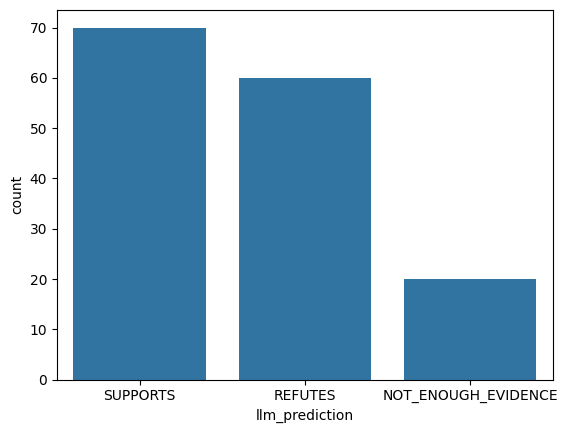

In [6]:
import seaborn as sns
sns.barplot(df_eval["llm_prediction"].value_counts())

In [9]:
y_true

0      0
2      0
4      0
5      0
6      0
      ..
144    0
145    0
146    1
147    0
148    1
Name: claim_label, Length: 130, dtype: int64

In [14]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score, recall_score

val_auc = roc_auc_score(y_true, [0]*len(y_true))
test_f1 = f1_score(y_true, [0]*len(y_true))
test_acc = accuracy_score(y_true, [0]*len(y_true))

print("test_auc: ", val_auc)
print("test_f1: ", test_f1)
print("test_acc: ", test_acc)
print("\nClassification report:")
print(classification_report(y_true, [0]*len(y_true), target_names=["REFUTES", "SUPPORTS"]))

test_auc:  0.5
test_f1:  0.0
test_acc:  0.7769230769230769

Classification report:
              precision    recall  f1-score   support

     REFUTES       0.78      1.00      0.87       101
    SUPPORTS       0.00      0.00      0.00        29

    accuracy                           0.78       130
   macro avg       0.39      0.50      0.44       130
weighted avg       0.60      0.78      0.68       130



c:\Applications\Git-OpenClassrooms\DS_8\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Applications\Git-OpenClassrooms\DS_8\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Applications\Git-OpenClassrooms\DS_8\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c